# Laboratorio 4, Parte 2 — avance de los ejercicios 1, 2 y 3

**CC3084 — Data Science · Universidad del Valle de Guatemala · 2026**

Este cuaderno construye y audita el conjunto de datos para *Machine Learning*, define la respuesta binaria de alta presencia de cianobacteria y selecciona un conjunto de predictores sin fuga de información. Cada resultado numérico se obtiene de los 22 rásteres de la Parte I; no se descargan escenas nuevas.

> **Unidad de observación:** un píxel de agua válido de 10 × 10 m, asociado a lago, fecha, coordenadas UTM, bandas e índices.


## 0. Preparación del entorno


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def localizar_proyecto(inicio=None):
    inicio = Path(inicio or Path.cwd()).resolve()
    for candidato in [inicio, *inicio.parents]:
        if candidato.name == "l04_analisis_geoespacial" and (candidato / "data").exists():
            return candidato
        anidado = candidato / "l04_analisis_geoespacial"
        if (anidado / "data").exists():
            return anidado
    raise FileNotFoundError("No se encontró l04_analisis_geoespacial.")


PROJECT_DIR = localizar_proyecto()
SRC_DIR = PROJECT_DIR / "parte_2" / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from preparar_ml import (
    CRS_ANALISIS,
    PREDICTORES_BASE,
    UMBRAL_ALERTA_CHL,
    VARIABLES_PROHIBIDAS,
    auditar_predictores,
    ejecutar_pipeline,
    inventariar_escenas,
)

OUTPUT_DIR = PROJECT_DIR / "parte_2" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})

resultado = ejecutar_pipeline(PROJECT_DIR, reutilizar=True)
manifest = resultado["manifest"]
print(f"Proyecto: {PROJECT_DIR}")
print(f"Dataset: {resultado['dataset_dir']}")
print(f"Versión del pipeline: {manifest['pipeline_version']}")


Proyecto: C:\Projects\Data-Science\l04_analisis_geoespacial
Dataset: C:\Projects\Data-Science\l04_analisis_geoespacial\parte_2\data\processed\dataset_ml
Versión del pipeline: 4


# 1. Preparación de los datos para Machine Learning

## 1.1 Integridad de fuentes y unidad de observación

Se exigen exactamente 22 escenas oficiales (11 por lago). Para cada fecha deben existir y estar alineados: el GeoTIFF de nueve bandas, NDVI, NDWI y clorofila-a/cianobacteria. La validación comprueba CRS, transformación, dimensiones, resolución y orden de bandas antes de combinar cualquier píxel.

El dataset se guarda como **Parquet particionado por lago y fecha**, lo cual permite conservar todos los píxeles válidos sin cargar más de 13 millones de filas simultáneamente en memoria.


In [2]:
inventario = inventariar_escenas(PROJECT_DIR)
assert len(inventario) == 22
assert inventario["crs"].eq(CRS_ANALISIS).all()
assert inventario["resolucion_m"].eq(10).all()

display(
    inventario.groupby("lago").agg(
        escenas=("fecha", "count"),
        primera_fecha=("fecha", "min"),
        ultima_fecha=("fecha", "max"),
        alto=("alto", "first"),
        ancho=("ancho", "first"),
    )
)
print("Validación superada: 22 escenas y cuatro fuentes alineadas por escena.")


,escenas,primera_fecha,ultima_fecha,alto,ancho
lago,,,,,
amatitlan,11,2025-01-28,2026-06-19,917,1360
atitlan,11,2025-01-18,2026-07-22,1751,2759


Validación superada: 22 escenas y cuatro fuentes alineadas por escena.


## 1.2 Variables incluidas

Las nueve bandas se leen como reflectancia escalada (`DN / 10000`). Se conservan NDVI, NDWI y la estimación continua de clorofila-a, aunque varias de estas columnas se excluirán de los predictores por fuga de información. Las coordenadas están en **WGS 84 / UTM zona 15N (EPSG:32615)** y expresadas en metros.


In [3]:
resumen_variables = pd.read_csv(resultado["variables"])
catalogo = pd.read_csv(resultado["catalogo"])
display(resumen_variables)


,variable,tipo_dato,valores_faltantes,pct_faltantes,observaciones_evaluadas,descripcion,familia
0,lago,object,0,0.0,13689403,Identificador del lago,espacial/categórica
1,fecha,datetime64[s],0,0.0,13689403,Fecha de adquisición,temporal/identificador
2,fila,int32,0,0.0,13689403,Fila del píxel en el ráster,identificador
3,columna,int32,0,0.0,13689403,Columna del píxel en el ráster,identificador
4,x_utm,float32,0,0.0,13689403,Coordenada este en EPSG:32615 (m),espacial
5,y_utm,float32,0,0.0,13689403,Coordenada norte en EPSG:32615 (m),espacial
6,b02,float32,0,0.0,13689403,Reflectancia azul Sentinel-2,banda espectral
7,b03,float32,0,0.0,13689403,Reflectancia verde Sentinel-2,banda espectral
8,b04,float32,0,0.0,13689403,Reflectancia roja Sentinel-2,banda espectral
9,b05,float32,0,0.0,13689403,Reflectancia red-edge 1 Sentinel-2,banda espectral


## 1.3 Limpieza y control de calidad

Se aplican, en este orden, los siguientes criterios:

1. **Límite del lago:** como la Parte I no incluye un polígono oficial, se aproxima el cuerpo de agua mediante persistencia multitemporal: el píxel debe haber sido clasificado como agua en al menos 3 de las 11 fechas del lago.
2. **Máscara válida de la Parte I:** la clorofila-a debe ser finita; esto elimina tierra y áreas que el flujo CyanoLakes no reconoció como agua en esa fecha.
3. **NoData:** todas las bandas requeridas deben tener dato.
4. **Valores físicamente plausibles:** se admite el intervalo amplio `[-0.1, 1.2]`; reflectancias L2A ligeramente negativas pueden aparecer tras la corrección atmosférica sobre agua oscura y no se confunden con NoData.
5. **Índices válidos:** NDVI y NDWI deben ser finitos y pertenecer a `[-1, 1]`.
6. **Nubes:** ninguna escena supera 20 % de nubosidad y se retiran píxeles simultáneamente brillantes en visible y SWIR. La ausencia de SCL impide afirmar una máscara de nubes perfecta; esta limitación debe mantenerse en el informe.

No se usa un filtro de desviaciones estándar: podría eliminar precisamente los extremos espectrales de una floración real.


In [4]:
limpieza = pd.read_csv(resultado["limpieza"])
columnas_limpieza = [
    "lago", "fecha", "pixeles_totales_bbox", "pixeles_objetivo_valido",
    "descartados_nodata_bandas", "descartados_reflectancia",
    "descartados_indices", "descartados_nube_brilante",
    "observaciones_validas", "pct_conservado_bbox",
]
display(limpieza[columnas_limpieza])
assert (limpieza["observaciones_validas"] > 0).all()


,lago,fecha,pixeles_totales_bbox,pixeles_objetivo_valido,descartados_nodata_bandas,descartados_reflectancia,descartados_indices,descartados_nube_brilante,observaciones_validas,pct_conservado_bbox
0,amatitlan,2025-01-28,1247120,147442,13,0,4695,6,141852,11.374367
1,amatitlan,2025-04-15,1247120,144535,0,0,272,4,144251,11.566730
2,amatitlan,2025-04-28,1247120,144731,0,0,0,8,144700,11.602733
3,amatitlan,2025-11-24,1247120,147330,6,0,3025,21,143545,11.510119
4,amatitlan,2026-01-08,1247120,148399,0,0,761,20,146461,11.743938
5,amatitlan,2026-02-02,1247120,145496,0,0,31,19,145437,11.661829
6,amatitlan,2026-02-07,1247120,146746,69328,0,12185,0,65188,5.227083
7,amatitlan,2026-03-29,1247120,146463,0,0,105,10,146330,11.733434
8,amatitlan,2026-04-13,1247120,147301,0,0,148,12,147070,11.792771
9,amatitlan,2026-04-28,1247120,141031,0,0,0,7,139628,11.196036


## 1.4 Tamaño, observaciones por lago/fecha y valores faltantes


In [5]:
resumen_lago = pd.read_csv(resultado["lago"])
resumen_fecha = pd.read_csv(resultado["lago_fecha"], parse_dates=["fecha"])

print(f"Observaciones totales: {manifest['observaciones_totales']:,}")
display(resumen_lago)
display(resumen_fecha)

assert resumen_fecha["observaciones_validas"].sum() == manifest["observaciones_totales"]
assert resumen_variables["pct_faltantes"].eq(0).all()
print("Porcentaje de valores faltantes después de la limpieza: 0 % en todas las variables.")


Observaciones totales: 13,689,403


,lago,observaciones_validas,n_clase_0,n_clase_1,pct_clase_1
0,amatitlan,1500358,1365448,134910,8.991854
1,atitlan,12189045,12186247,2798,0.022955


,lago,fecha,observaciones_validas,n_clase_0,n_clase_1,pct_clase_1
0,amatitlan,2025-01-28,141852,141818,34,0.023969
1,amatitlan,2025-04-15,144251,143864,387,0.268282
2,amatitlan,2025-04-28,144700,138307,6393,4.418106
3,amatitlan,2025-11-24,143545,140981,2564,1.786199
4,amatitlan,2026-01-08,146461,137800,8661,5.913520
5,amatitlan,2026-02-02,145437,145410,27,0.018565
6,amatitlan,2026-02-07,65188,65187,1,0.001534
7,amatitlan,2026-03-29,146330,136654,9676,6.612451
8,amatitlan,2026-04-13,147070,145008,2062,1.402053
9,amatitlan,2026-04-28,139628,95701,43927,31.460022


Porcentaje de valores faltantes después de la limpieza: 0 % en todas las variables.


## 1.5 Análisis exploratorio

Los conteos y porcentajes de la respuesta se calculan sobre **todo** el dataset. Para gráficos multivariados se usa una muestra reproducible de hasta 10,000 píxeles por escena (220,000 filas como máximo), de modo que ninguna fecha grande monopolice las visualizaciones. Esta muestra no reemplaza los conteos exactos.


Tamaño de la muestra EDA: 220,000


,count,mean,std,min,25%,50%,75%,max
b07,220000.0,1.995185e-02,0.024127,-1.640000e-02,5.100000e-03,1.110000e-02,2.750000e-02,5.659000e-01
b8a,220000.0,1.583317e-02,0.019239,-1.890000e-02,3.700000e-03,9.300000e-03,2.270000e-02,5.338000e-01
x_utm,220000.0,7.283924e+05,34228.878906,6.810650e+05,6.942850e+05,7.325800e+05,7.627350e+05,7.670650e+05
y_utm,220000.0,1.612519e+06,13287.069336,1.594635e+06,1.598875e+06,1.608885e+06,1.625775e+06,1.631555e+06
sin_dia_anio,220000.0,4.729931e-01,0.534598,-6.354321e-01,1.372788e-01,6.414603e-01,9.721182e-01,9.984354e-01
cos_dia_anio,220000.0,1.030973e-01,0.692717,-9.769385e-01,-4.443783e-01,-7.248685e-02,8.039280e-01,9.994074e-01
dias_desde_inicio,220000.0,3.095909e+02,168.332214,0.000000e+00,1.150000e+02,3.675000e+02,4.500000e+02,5.500000e+02
alta_cyano,220000.0,4.455000e-02,0.206314,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00


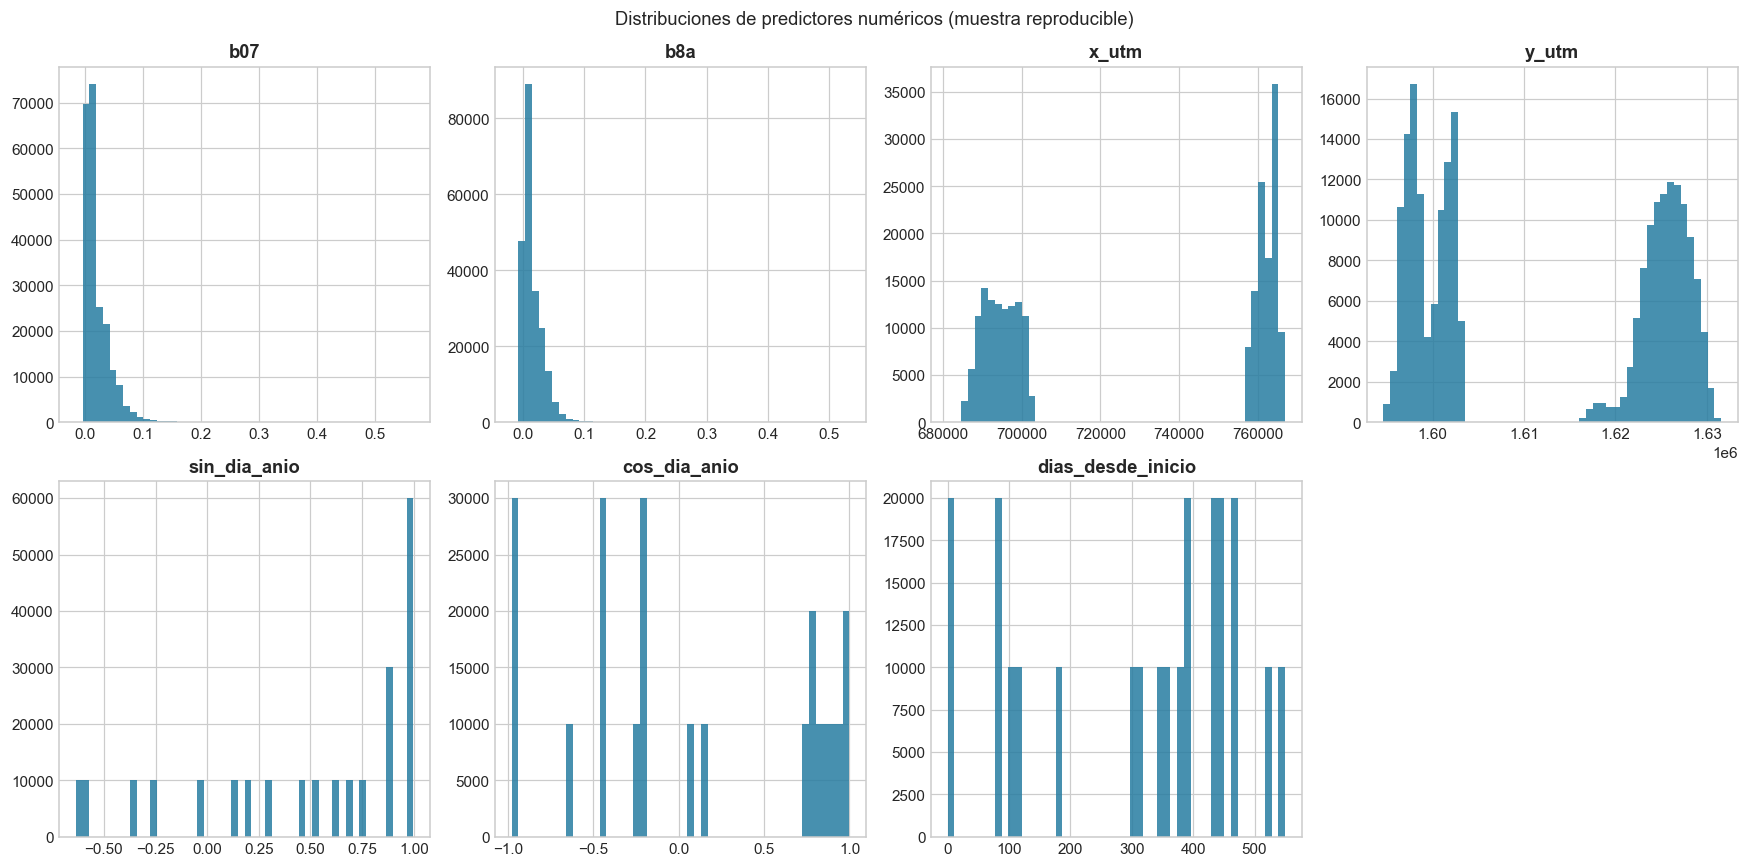

In [6]:
muestra = pd.read_parquet(resultado["muestra"])
print(f"Tamaño de la muestra EDA: {len(muestra):,}")

variables_eda = ["b07", "b8a", "x_utm", "y_utm", "sin_dia_anio", "cos_dia_anio", "dias_desde_inicio"]
display(muestra[variables_eda + ["alta_cyano"]].describe().T)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, variable in zip(axes.flat, variables_eda):
    ax.hist(muestra[variable], bins=50, color="#277DA1", alpha=0.85)
    ax.set_title(variable)
axes.flat[-1].axis("off")
fig.suptitle("Distribuciones de predictores numéricos (muestra reproducible)")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "01_distribuciones_predictores.png", dpi=180, bbox_inches="tight")
plt.show()


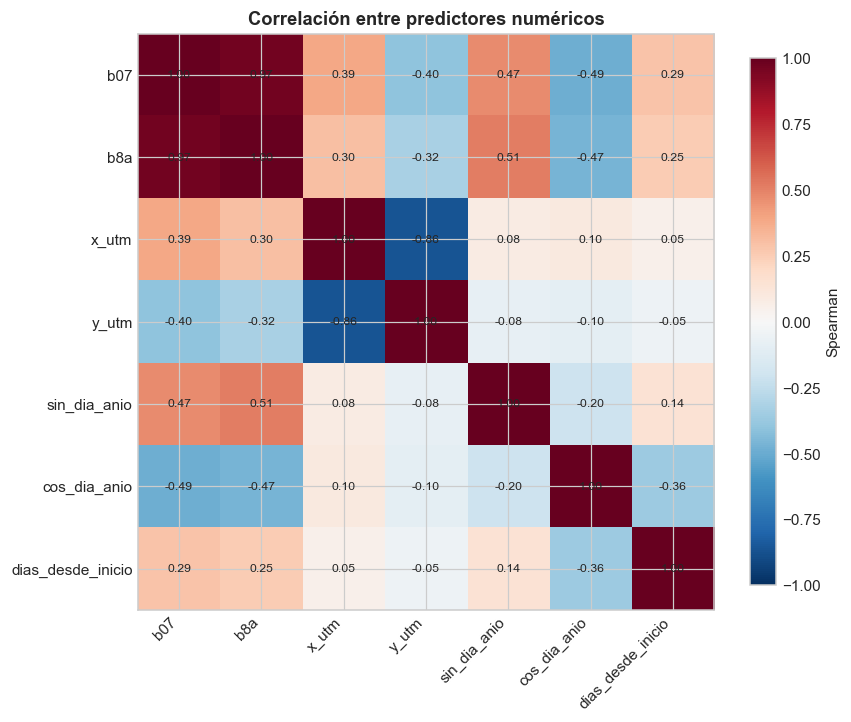

Pares con |rho| >= 0.90: [('b07', 'b8a', np.float64(0.9656785727337587))]


In [7]:
correlacion = muestra[variables_eda].corr(method="spearman")
fig, ax = plt.subplots(figsize=(8, 7))
imagen = ax.imshow(correlacion, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(correlacion)), correlacion.columns, rotation=45, ha="right")
ax.set_yticks(range(len(correlacion)), correlacion.columns)
for i in range(len(correlacion)):
    for j in range(len(correlacion)):
        ax.text(j, i, f"{correlacion.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(imagen, ax=ax, shrink=0.8, label="Spearman")
ax.set_title("Correlación entre predictores numéricos")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "02_correlacion_predictores.png", dpi=180, bbox_inches="tight")
plt.show()

alta_correlacion = [
    (a, b, correlacion.loc[a, b])
    for i, a in enumerate(correlacion.columns)
    for b in correlacion.columns[i + 1:]
    if abs(correlacion.loc[a, b]) >= 0.90
]
print("Pares con |rho| >= 0.90:", alta_correlacion or "ninguno")


## 1.6 Decisiones principales

- Se conserva la resolución nativa de 10 m porque el objetivo del laboratorio es modelar zonas dentro del lago, no promedios por escena.
- El límite persistente reduce falsos positivos aislados sin requerir descargar una geometría nueva; aun así, una futura versión debería usar polígonos oficiales.
- No se imputan bandas, índices ni etiqueta. Imputar la respuesta inventaría presencia/ausencia y la interpolación espacial de reflectancia podría suavizar una floración.
- La clorofila-a negativa se trunca a cero: una concentración negativa no tiene interpretación física y no afecta el corte alto de 12 µg/L.
- Parquet conserva tipos y comprime el dataset; el particionamiento permite lectura selectiva por lago/fecha.


# 2. Construcción de la variable respuesta

## 2.1–2.2 Definición binaria y punto de corte

Se define `alta_cyano = 0` para `chl_cyano < 12 µg/L` y `alta_cyano = 1` para `chl_cyano ≥ 12 µg/L`.

La **OMS (2021)** establece, para aguas recreativas dulces con dominancia de cianobacterias, un nivel de vigilancia de **1–12 µg/L de clorofila-a** y un nivel de alerta 1 de **12–24 µg/L**. Por eso 12 µg/L es un punto de corte operativo y científicamente defendible entre biomasa baja/vigilancia y presencia elevada que amerita gestión. El nivel de alerta 2 depende de *scum* o transparencia menor de 0.5–1 m; no puede deducirse únicamente de este ráster.

La etiqueta no confirma toxicidad: la clorofila-a estimada por NDCI es un indicador de biomasa, no un recuento celular, biovolumen o medición de cianotoxinas. Un positivo debe interpretarse como prioridad para verificación de campo.

**Bibliografía científica y normativa**

- World Health Organization. (2021). *Guidelines on recreational water quality. Volume 1: Coastal and fresh waters*. ISBN 978-92-4-003130-2. https://www.who.int/publications/b/58742
- World Health Organization. (2021). *Compendium of WHO and other UN guidance on health and environment*, tabla 3.2. https://cdn.who.int/media/docs/default-source/who-compendium-on-health-and-environment/who_compendium_chapter3_27082021_pdf.pdf
- Mishra, S., & Mishra, D. R. (2012). Normalized difference chlorophyll index: A novel model for remote estimation of chlorophyll-a concentration in turbid productive waters. *Remote Sensing of Environment, 117*, 394–406. https://doi.org/10.1016/j.rse.2011.10.016


In [8]:
print(f"Umbral operativo: {UMBRAL_ALERTA_CHL:g} µg/L")
print("0 = ausencia/baja presencia; 1 = presencia elevada / inicio de alerta 1")
assert manifest["umbral_alerta_chl_ug_l"] == UMBRAL_ALERTA_CHL


Umbral operativo: 12 µg/L
0 = ausencia/baja presencia; 1 = presencia elevada / inicio de alerta 1


## 2.3 Distribución global, por lago y por fecha


,clase,observaciones,porcentaje
0,0: ausencia/baja,13551695,98.994054
1,1: elevada/alerta,137708,1.005946


,lago,n_clase_0,n_clase_1,pct_clase_1
0,amatitlan,1365448,134910,8.991854
1,atitlan,12186247,2798,0.022955


,lago,fecha,n_clase_0,n_clase_1,pct_clase_1
0,amatitlan,2025-01-28,141818,34,0.023969
1,amatitlan,2025-04-15,143864,387,0.268282
2,amatitlan,2025-04-28,138307,6393,4.418106
3,amatitlan,2025-11-24,140981,2564,1.786199
4,amatitlan,2026-01-08,137800,8661,5.913520
5,amatitlan,2026-02-02,145410,27,0.018565
6,amatitlan,2026-02-07,65187,1,0.001534
7,amatitlan,2026-03-29,136654,9676,6.612451
8,amatitlan,2026-04-13,145008,2062,1.402053
9,amatitlan,2026-04-28,95701,43927,31.460022


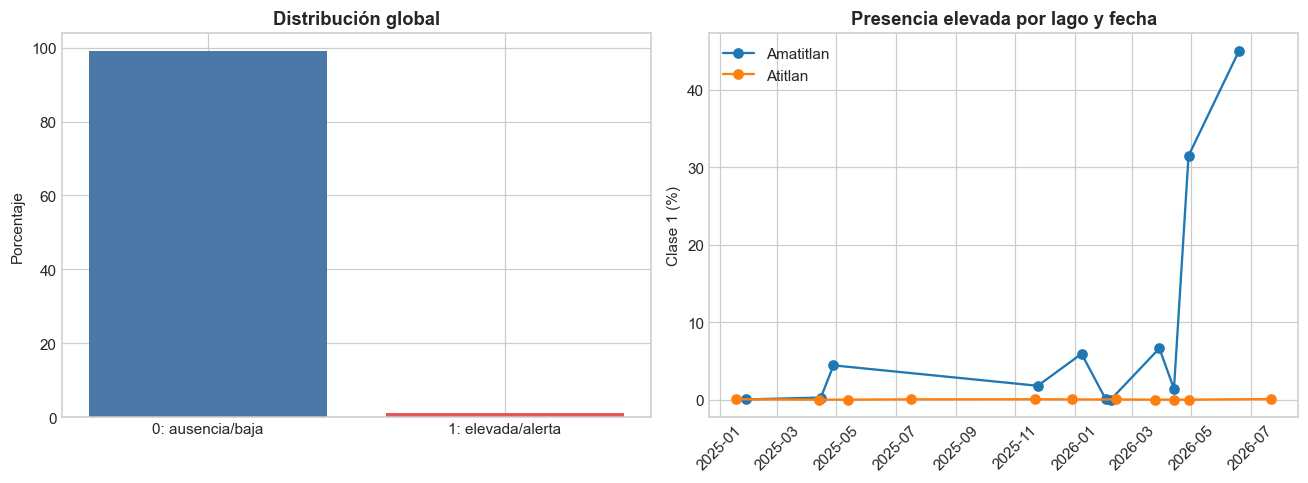

In [9]:
global_respuesta = pd.DataFrame({
    "clase": ["0: ausencia/baja", "1: elevada/alerta"],
    "observaciones": [manifest["n_clase_0"], manifest["n_clase_1"]],
})
global_respuesta["porcentaje"] = 100 * global_respuesta["observaciones"] / global_respuesta["observaciones"].sum()
display(global_respuesta)
display(resumen_lago[["lago", "n_clase_0", "n_clase_1", "pct_clase_1"]])
display(resumen_fecha[["lago", "fecha", "n_clase_0", "n_clase_1", "pct_clase_1"]])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(global_respuesta["clase"], global_respuesta["porcentaje"], color=["#4C78A8", "#E45756"])
axes[0].set_ylabel("Porcentaje")
axes[0].set_title("Distribución global")
for lago, grupo in resumen_fecha.groupby("lago"):
    axes[1].plot(grupo["fecha"], grupo["pct_clase_1"], marker="o", label=lago.capitalize())
axes[1].set_ylabel("Clase 1 (%)")
axes[1].set_title("Presencia elevada por lago y fecha")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "03_distribucion_respuesta.png", dpi=180, bbox_inches="tight")
plt.show()


## 2.4 Desbalance de clases

La razón mayoría:minoría y la exactitud de un clasificador que siempre predice la mayoría permiten dimensionar el problema. Con desbalance severo, *accuracy* deja de ser suficiente: un modelo puede acertar casi todos los píxeles y no detectar ninguna zona de alerta.


In [10]:
n0, n1 = manifest["n_clase_0"], manifest["n_clase_1"]
razon = max(n0, n1) / min(n0, n1)
accuracy_ingenua = 100 * max(n0, n1) / (n0 + n1)
print(f"Razón mayoría:minoría = {razon:.2f}:1")
print(f"Accuracy ingenua (siempre clase 0) = {accuracy_ingenua:.3f}%")
print("Conclusión: desbalance severo." if razon >= 10 else "Conclusión: revisar desbalance.")


Razón mayoría:minoría = 98.41:1
Accuracy ingenua (siempre clase 0) = 98.994%
Conclusión: desbalance severo.


**Consecuencias para los modelos posteriores:** sesgo hacia clase 0, probabilidades mal calibradas y métricas globales engañosas. En el entrenamiento se deberán usar particiones por grupos espaciales/temporales, pesos de clase o remuestreo solo dentro del entrenamiento. La evaluación deberá priorizar *recall* de clase 1, precisión, F1, *balanced accuracy*, PR-AUC y matriz de confusión; ROC-AUC se reportará, pero PR-AUC es más informativa con positivos raros.


## 2.5 Auditoría de fuga de información


In [11]:
auditoria = pd.read_csv(resultado["auditoria"])
display(auditoria)
assert VARIABLES_PROHIBIDAS.isdisjoint(PREDICTORES_BASE)


,variable,decision,razon
0,lago,INCLUIR,Predictor base sin uso directo ni indirecto en...
1,fecha,EXCLUIR,"Identificador, variable redundante o no selecc..."
2,fila,EXCLUIR,"Identificador, variable redundante o no selecc..."
3,columna,EXCLUIR,"Identificador, variable redundante o no selecc..."
4,x_utm,INCLUIR,Predictor base sin uso directo ni indirecto en...
5,y_utm,INCLUIR,Predictor base sin uso directo ni indirecto en...
6,b02,EXCLUIR,Fuga: intervino en el valor o en la máscara qu...
7,b03,EXCLUIR,Fuga: intervino en el valor o en la máscara qu...
8,b04,EXCLUIR,Fuga: intervino en el valor o en la máscara qu...
9,b05,EXCLUIR,Fuga: intervino en el valor o en la máscara qu...


La exclusión debe ser más amplia que `chl_cyano`: el valor continuo proviene de NDCI (`B04`, `B05`) y la máscara de agua de la Parte I usa `B02`, `B03`, `B04`, `B08`, `B11`, `B12`, NDVI, NDWI, MNDWI, AWEI y DBSI. Todas esas variables intervinieron directa o indirectamente en la construcción de la etiqueta y se excluyen de `X`.

Se conservan en el dataset para trazabilidad, mapas y auditorías, pero la selección de columnas antes del entrenamiento será explícita. `fila`, `columna`, `fecha` y `nivel_biomasa_oms` tampoco forman parte de `X` por ser identificadores, representación sin transformar o derivación de la respuesta.


# 3. Selección y construcción de variables predictoras

## 3.1 Conjunto predictor propuesto

El conjunto principal es deliberadamente estricto y evita todas las bandas e índices usados en la etiqueta. Para modelos con ambos lagos se usarán las siguientes columnas; en generalización entre lagos se retirará `lago`, y se reportará un análisis de sensibilidad sin coordenadas para medir cuánto depende el desempeño de memorizar ubicación.


In [12]:
tabla_predictores = pd.DataFrame([
    ("b07", "Banda espectral", "Red-edge 3 (~783 nm); puede captar cambios de reflectancia asociados con biomasa y materia suspendida.", "Estandarizar en modelos lineales."),
    ("b8a", "Banda espectral", "NIR estrecha (~865 nm); aporta contraste en agua y floraciones sin usar las bandas del NDCI.", "Estandarizar; revisar colinealidad con B07."),
    ("x_utm", "Espacial", "Posición este en metros; puede representar gradientes locales, entradas y zonas someras.", "Puede memorizar ubicación; validar por bloques."),
    ("y_utm", "Espacial", "Posición norte en metros; complementa los gradientes espaciales.", "Puede memorizar ubicación; validar por bloques."),
    ("sin_dia_anio", "Ingeniería temporal", "Componente seno de la estacionalidad anual.", "Evita la discontinuidad diciembre/enero."),
    ("cos_dia_anio", "Ingeniería temporal", "Componente coseno de la estacionalidad anual.", "Debe usarse junto con el seno."),
    ("dias_desde_inicio", "Ingeniería temporal", "Tendencia temporal desde la primera escena.", "Solo 22 escenas; controlar sobreajuste temporal."),
    ("lago", "Espacial/categórica", "Diferencias estructurales entre Atitlán y Amatitlán.", "Excluir al evaluar transferencia entre lagos."),
    ("nubosidad_pct", "Calidad", "Calidad atmosférica global de la escena.", "Covariable de control; no representa una condición ecológica."),
    ("satelite", "Categórica", "Plataforma Sentinel-2 A/B/C; controla diferencias instrumentales.", "Retirar si induce atajos específicos de fecha."),
], columns=["variable", "tipo", "aporte_potencial", "precaucion"])

assert tabla_predictores["variable"].tolist() == PREDICTORES_BASE
display(tabla_predictores)


,variable,tipo,aporte_potencial,precaucion
0,b07,Banda espectral,Red-edge 3 (~783 nm); puede captar cambios de ...,Estandarizar en modelos lineales.
1,b8a,Banda espectral,NIR estrecha (~865 nm); aporta contraste en ag...,Estandarizar; revisar colinealidad con B07.
2,x_utm,Espacial,Posición este en metros; puede representar gra...,Puede memorizar ubicación; validar por bloques.
3,y_utm,Espacial,Posición norte en metros; complementa los grad...,Puede memorizar ubicación; validar por bloques.
4,sin_dia_anio,Ingeniería temporal,Componente seno de la estacionalidad anual.,Evita la discontinuidad diciembre/enero.
5,cos_dia_anio,Ingeniería temporal,Componente coseno de la estacionalidad anual.,Debe usarse junto con el seno.
6,dias_desde_inicio,Ingeniería temporal,Tendencia temporal desde la primera escena.,Solo 22 escenas; controlar sobreajuste temporal.
7,lago,Espacial/categórica,Diferencias estructurales entre Atitlán y Amat...,Excluir al evaluar transferencia entre lagos.
8,nubosidad_pct,Calidad,Calidad atmosférica global de la escena.,Covariable de control; no representa una condi...
9,satelite,Categórica,Plataforma Sentinel-2 A/B/C; controla diferenc...,Retirar si induce atajos específicos de fecha.


## 3.2 Justificación y escenarios de uso

- **Espectrales:** B07 y B8A son las únicas bandas disponibles que no intervinieron en NDCI ni en la máscara de agua de la etiqueta. Se evita construir otro índice con las bandas prohibidas.
- **Espaciales:** `x_utm`/`y_utm` pueden capturar heterogeneidad dentro de los lagos, pero requieren validación espacial estricta; de lo contrario inflan el desempeño.
- **Temporales:** seno/coseno representan estacionalidad y `dias_desde_inicio` una tendencia de largo plazo. La fecha cruda se conserva como identificador, no como número arbitrario.
- **Contexto/calidad:** `lago`, `nubosidad_pct` y `satelite` se incluyen como controles en el modelo mixto, con ablaciones para detectar atajos.

No se agrega una razón B07/B8A al conjunto principal: sería una transformación determinista de dos bandas ya presentes y puede aumentar colinealidad en regresión logística sin demostrar información nueva. Los modelos de árboles podrán capturar interacciones no lineales entre ambas bandas.


## 3.3 Evaluación preliminar de capacidad predictiva y redundancia


,media_clase_0,media_clase_1,mediana_clase_0,mediana_clase_1,d_estandarizada
b07,1.729891e-02,7.684846e-02,1.040000e-02,6.740000e-02,2.867857
b8a,1.413819e-02,5.218472e-02,8.700000e-03,4.430000e-02,2.166063
nubosidad_pct,1.920327e+00,7.728707e+00,5.400000e-01,4.960000e+00,2.136919
x_utm,7.268654e+05,7.611414e+05,7.012850e+05,7.607450e+05,1.023453
cos_dia_anio,1.331766e-01,-5.420045e-01,5.591689e-02,-4.443783e-01,-0.995009
y_utm,1.613077e+06,1.600561e+06,1.620925e+06,1.601415e+06,-0.960265
dias_desde_inicio,3.026133e+02,4.592363e+02,3.550000e+02,4.650000e+02,0.948069
sin_dia_anio,4.710840e-01,5.139400e-01,6.744437e-01,2.135210e-01,0.080176


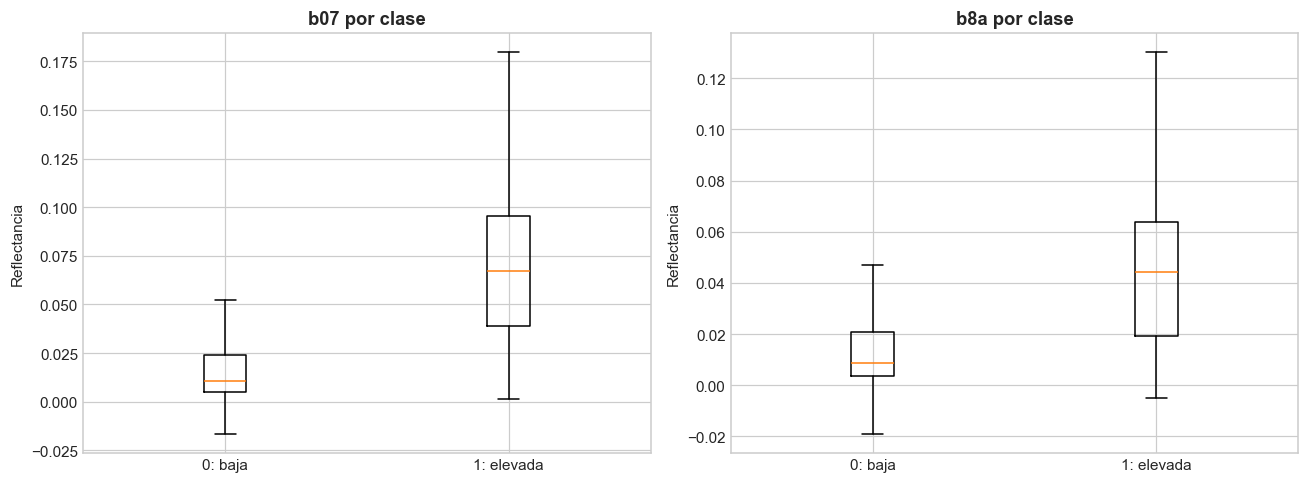

In [13]:
numericos = [c for c in PREDICTORES_BASE if c in muestra.select_dtypes(include="number").columns]

def diferencia_estandarizada(datos, variable, objetivo="alta_cyano"):
    g0 = datos.loc[datos[objetivo] == 0, variable].dropna()
    g1 = datos.loc[datos[objetivo] == 1, variable].dropna()
    var_pooled = ((len(g0) - 1) * g0.var() + (len(g1) - 1) * g1.var()) / max(len(g0) + len(g1) - 2, 1)
    d = (g1.mean() - g0.mean()) / np.sqrt(var_pooled) if var_pooled > 0 else np.nan
    return pd.Series({
        "media_clase_0": g0.mean(), "media_clase_1": g1.mean(),
        "mediana_clase_0": g0.median(), "mediana_clase_1": g1.median(),
        "d_estandarizada": d,
    })

efectos = pd.DataFrame({v: diferencia_estandarizada(muestra, v) for v in numericos}).T
display(efectos.sort_values("d_estandarizada", key=lambda s: s.abs(), ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, variable in zip(axes, ["b07", "b8a"]):
    datos_box = [
        muestra.loc[muestra["alta_cyano"] == clase, variable].to_numpy()
        for clase in [0, 1]
    ]
    ax.boxplot(datos_box, tick_labels=["0: baja", "1: elevada"], showfliers=False)
    ax.set_title(f"{variable} por clase")
    ax.set_ylabel("Reflectancia")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "04_bandas_por_clase.png", dpi=180, bbox_inches="tight")
plt.show()


In [14]:
tasas_muestra = []
for variable in ["lago", "satelite"]:
    tabla = muestra.groupby(variable, observed=True)["alta_cyano"].agg(["count", "mean"]).reset_index()
    tabla["pct_clase_1"] = 100 * tabla["mean"]
    tabla["variable"] = variable
    tasas_muestra.append(tabla[["variable", variable, "count", "pct_clase_1"]].rename(columns={variable: "categoria"}))
display(pd.concat(tasas_muestra, ignore_index=True))

print("Estas tasas categóricas son diagnósticas sobre la muestra EDA; los conteos exactos por lago se reportaron en 2.3.")


,variable,categoria,count,pct_clase_1
0,lago,amatitlan,110000,8.884545
1,lago,atitlan,110000,0.025455
2,satelite,Sentinel-2A,40000,11.475000
3,satelite,Sentinel-2B,100000,0.769000
4,satelite,Sentinel-2C,80000,5.552500


Estas tasas categóricas son diagnósticas sobre la muestra EDA; los conteos exactos por lago se reportaron en 2.3.


**Interpretación preliminar.** Una diferencia entre clases no demuestra causalidad ni garantiza generalización. La concentración de positivos en ciertas fechas o en Amatitlán puede hacer que coordenadas, lago, satélite o tendencia funcionen como atajos. Por eso, en el ejercicio 4 se deberá comparar: (a) conjunto completo; (b) sin `lago`, `nubosidad_pct` y `satelite`; y (c) sin coordenadas. La selección final debe basarse en validación espacial/temporal, no solo en asociaciones de esta muestra.


## Comprobaciones finales del avance 1–3


In [15]:
assert manifest["numero_escenas"] == 22
assert manifest["observaciones_totales"] > 0
assert manifest["n_clase_0"] > 0 and manifest["n_clase_1"] > 0
assert resumen_variables["pct_faltantes"].eq(0).all()
assert set(PREDICTORES_BASE).issubset(muestra.columns)
assert VARIABLES_PROHIBIDAS.isdisjoint(PREDICTORES_BASE)
assert muestra[PREDICTORES_BASE].notna().all().all()

print("✓ 22 escenas alineadas")
print(f"✓ {manifest['observaciones_totales']:,} observaciones válidas")
print("✓ Sin valores faltantes en el dataset limpio")
print("✓ Respuesta binaria reproducible con umbral OMS 2021")
print("✓ Predictores presentes y sin fuga conocida")
print("✓ Ejercicios 1, 2 y 3 listos")


✓ 22 escenas alineadas
✓ 13,689,403 observaciones válidas
✓ Sin valores faltantes en el dataset limpio
✓ Respuesta binaria reproducible con umbral OMS 2021
✓ Predictores presentes y sin fuga conocida
✓ Ejercicios 1, 2 y 3 listos


# 4. Construcción de modelos de Machine Learning

## 4.1–4.2 Modelos y división convencional 70/30

Se comparan tres familias: **Regresión Logística**, **Random Forest** y **XGBoost**. XGBoost es una implementación optimizada de *gradient boosting*; por tanto, cumple el requisito de Gradient Boosting o XGBoost del enunciado.

Para que el experimento sea reproducible y computacionalmente viable, se toma una muestra aleatoria **proporcional por lago y fecha de 600,000 observaciones** del dataset limpio completo. Esta muestra conserva la prevalencia global aproximada de la clase positiva. Se realiza una única división aleatoria estratificada:

- 70 % entrenamiento: 420,000 observaciones.
- 30 % prueba: 180,000 observaciones.
- `random_state=42` y estratificación por `alta_cyano`.

Los tres modelos reciben exactamente las mismas filas de entrenamiento y prueba. El conjunto de prueba no participa en la selección de hiperparámetros ni del umbral operativo.


In [16]:
from modelar_ml import (
    CONFIGURACIONES,
    PREDICTORAS,
    RANDOM_STATE,
    ejecutar_modelos,
)
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_curve,
)

resultado_modelos = ejecutar_modelos(PROJECT_DIR, reutilizar=True)
manifest_modelos = resultado_modelos["manifest_data"]
metricas_05 = pd.read_csv(resultado_modelos["metricas_05"])
metricas_operativas = pd.read_csv(resultado_modelos["metricas_operativas"])
busqueda = pd.read_csv(resultado_modelos["busqueda"])
predicciones_test = pd.read_parquet(resultado_modelos["predicciones"])

resumen_split = pd.DataFrame({
    "particion": ["Entrenamiento", "Prueba"],
    "observaciones": [manifest_modelos["train_n"], manifest_modelos["test_n"]],
    "porcentaje": [70.0, 30.0],
    "positivos": [manifest_modelos["positivos_train"], manifest_modelos["positivos_test"]],
})
display(resumen_split)
print(f"Prevalencia positiva en la muestra: {100 * manifest_modelos['prevalencia_muestra']:.3f}%")
print(f"Huella SHA-256 del test común: {manifest_modelos['test_sha256']}")

assert manifest_modelos["train_n"] == 420_000
assert manifest_modelos["test_n"] == 180_000
assert manifest_modelos["predictores"] == PREDICTORAS


,particion,observaciones,porcentaje,positivos
0,Entrenamiento,420000,70.0,4213
1,Prueba,180000,30.0,1806


Prevalencia positiva en la muestra: 1.003%
Huella SHA-256 del test común: c76dcdc95aab3d65e25912e353692fafdd2b685d9bc98a6f319258cc7b8b359c


### Preprocesamiento y desbalance

- **Regresión Logística:** estandarización de variables numéricas, codificación *one-hot* de `lago` y `satelite`, regularización L2 y `class_weight="balanced"`.
- **Random Forest:** codificación *one-hot*, `class_weight="balanced_subsample"` y paralelización de árboles.
- **XGBoost:** codificación *one-hot*, árboles de *gradient boosting* con el método `hist` y `scale_pos_weight=98.7` para compensar la razón aproximada de 99 negativos por positivo.

Los pesos de clase se calculan únicamente con las frecuencias del entrenamiento. No se sobremuestrea el test ni se altera su prevalencia.


## 4.3 Ajuste de hiperparámetros

El 70 % de entrenamiento se divide internamente en 80 % ajuste y 20 % validación, siempre de forma estratificada. El criterio principal de selección es **PR-AUC** en validación, por ser más informativo con una clase positiva cercana al 1 %; F2 se usa como desempate.

Valores evaluados:

- **Regresión Logística:** `C ∈ {0.1, 1, 10}`. Valores menores implican mayor regularización.
- **Random Forest:** 160–240 árboles, profundidad máxima 14, 20 o ilimitada, `min_samples_leaf ∈ {3, 5, 10}` y `max_features ∈ {sqrt, 0.7}`.
- **XGBoost:** 220–300 árboles, `max_depth ∈ {4, 5, 6}`, `learning_rate ∈ {0.05, 0.08}`, `min_child_weight ∈ {2, 3, 5}`, `subsample ∈ {0.85, 0.90}` y `colsample_bytree ∈ {0.80, 0.85, 0.90}`.

Después de seleccionar la configuración, cada modelo se vuelve a entrenar con todo el 70 %. Además, sobre la validación interna se escoge un umbral que maximiza **F2**, métrica que da cuatro veces más peso al *recall* que a la precisión.


In [17]:
columnas_busqueda = [
    "modelo", "configuracion", "parametros", "pr_auc_validacion",
    "roc_auc_validacion", "f2_validacion", "umbral_f2_validacion",
    "segundos_ajuste",
]
display(busqueda[columnas_busqueda].sort_values(["modelo", "configuracion"]))

elegidos = pd.DataFrame([
    {
        "modelo": modelo,
        "parametros_elegidos": parametros,
        "umbral_operativo": manifest_modelos["umbrales_operativos"][modelo],
    }
    for modelo, parametros in manifest_modelos["parametros_elegidos"].items()
])
display(elegidos)


,modelo,configuracion,parametros,pr_auc_validacion,roc_auc_validacion,f2_validacion,umbral_f2_validacion,segundos_ajuste
3,Random Forest,1,"{""max_depth"": 14, ""max_features"": ""sqrt"", ""min...",0.953645,0.999397,0.914087,0.554242,18.471187
4,Random Forest,2,"{""max_depth"": 20, ""max_features"": ""sqrt"", ""min...",0.960689,0.997754,0.926941,0.429184,27.472221
5,Random Forest,3,"{""max_depth"": null, ""max_features"": 0.7, ""min_...",0.958454,0.998329,0.922592,0.515439,46.323195
0,Regresión Logística,1,"{""C"": 0.1}",0.822251,0.996432,0.859580,0.948454,1.919530
1,Regresión Logística,2,"{""C"": 1.0}",0.822452,0.996425,0.860215,0.950956,1.715839
2,Regresión Logística,3,"{""C"": 10.0}",0.822469,0.996416,0.859838,0.951581,1.688452
6,XGBoost,1,"{""colsample_bytree"": 0.85, ""learning_rate"": 0....",0.919704,0.998953,0.897065,0.925006,3.371439
7,XGBoost,2,"{""colsample_bytree"": 0.9, ""learning_rate"": 0.0...",0.950586,0.999310,0.923567,0.922564,4.917332
8,XGBoost,3,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",0.961273,0.999456,0.926807,0.817227,5.860304


,modelo,parametros_elegidos,umbral_operativo
0,Regresión Logística,{'C': 10.0},0.951581
1,Random Forest,"{'n_estimators': 240, 'max_depth': 20, 'min_sa...",0.429184
2,XGBoost,"{'n_estimators': 260, 'max_depth': 6, 'learnin...",0.817227


## 4.4 Conjunto de prueba común

La huella SHA-256 mostrada arriba identifica las 180,000 observaciones de prueba mediante lago, fecha, fila y columna. Las probabilidades de los tres modelos se almacenan junto a esos mismos identificadores, lo que impide comparar accidentalmente métricas calculadas sobre conjuntos diferentes.


# 5. Evaluación de los modelos

## 5.1 Métricas y matrices de confusión

Se reportan las métricas solicitadas con el umbral convencional de 0.5. Debido al desbalance, también se añaden PR-AUC, F2, *balanced accuracy* y especificidad. Posteriormente se presenta la evaluación con el umbral operativo elegido exclusivamente en validación.


In [18]:
columnas_metricas = [
    "modelo", "umbral", "accuracy", "precision", "recall", "f1", "f2",
    "roc_auc", "pr_auc", "balanced_accuracy", "specificity", "tn", "fp", "fn", "tp",
]
print("Métricas con umbral convencional 0.5")
display(metricas_05[columnas_metricas].style.format({c: "{:.4f}" for c in columnas_metricas[1:11]}))

print("Métricas con umbral operativo seleccionado en validación")
display(metricas_operativas[columnas_metricas].style.format({c: "{:.4f}" for c in columnas_metricas[1:11]}))

metricas_05.to_csv(OUTPUT_DIR / "05_metricas_modelos_umbral_05.csv", index=False)
metricas_operativas.to_csv(OUTPUT_DIR / "05_metricas_modelos_umbral_operativo.csv", index=False)


Métricas con umbral convencional 0.5


,modelo,umbral,accuracy,precision,recall,f1,f2,roc_auc,pr_auc,balanced_accuracy,specificity,tn,fp,fn,tp
0,Regresión Logística,0.5000,0.9807,0.3408,0.9900,0.5070,0.7169,0.9978,0.8213,0.9853,0.9806,174735,3459,18,1788
1,Random Forest,0.5000,0.9977,0.8310,0.9662,0.8935,0.9358,0.9996,0.9667,0.9821,0.9980,177839,355,61,1745
2,XGBoost,0.5000,0.9956,0.6957,0.9911,0.8175,0.9135,0.9996,0.9592,0.9934,0.9956,177411,783,16,1790


Métricas con umbral operativo seleccionado en validación


,modelo,umbral,accuracy,precision,recall,f1,f2,roc_auc,pr_auc,balanced_accuracy,specificity,tn,fp,fn,tp
0,Regresión Logística,0.9516,0.9943,0.6530,0.9203,0.7640,0.8507,0.9978,0.8213,0.9577,0.9950,177311,883,144,1662
1,Random Forest,0.4292,0.9974,0.8044,0.9745,0.8813,0.9350,0.9996,0.9667,0.9861,0.9976,177766,428,46,1760
2,XGBoost,0.8172,0.9967,0.7626,0.9767,0.8565,0.9248,0.9996,0.9592,0.9868,0.9969,177645,549,42,1764


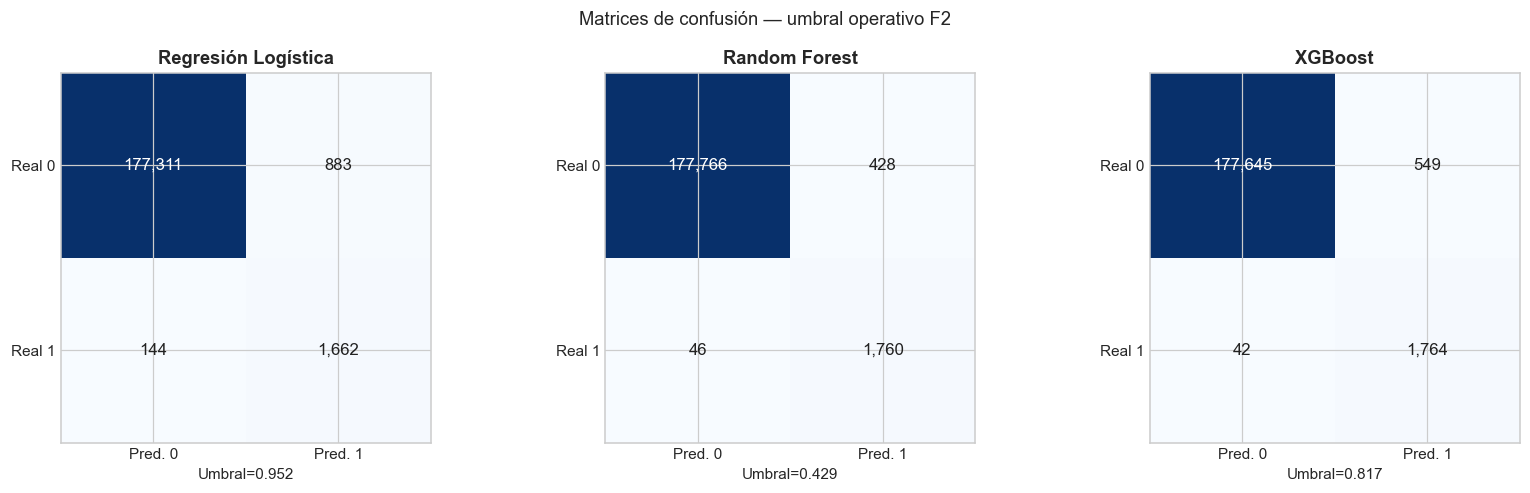

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, fila in zip(axes, metricas_operativas.itertuples(index=False)):
    matriz = np.array([[fila.tn, fila.fp], [fila.fn, fila.tp]])
    imagen = ax.imshow(matriz, cmap="Blues")
    for i in range(2):
        for j in range(2):
            color = "white" if matriz[i, j] > matriz.max() / 2 else "#222222"
            ax.text(j, i, f"{matriz[i, j]:,}", ha="center", va="center", fontsize=11, color=color)
    ax.set_xticks([0, 1], ["Pred. 0", "Pred. 1"])
    ax.set_yticks([0, 1], ["Real 0", "Real 1"])
    ax.set_title(fila.modelo)
    ax.set_xlabel(f"Umbral={fila.umbral:.3f}")
fig.suptitle("Matrices de confusión — umbral operativo F2")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "06_matrices_confusion.png", dpi=180, bbox_inches="tight")
plt.show()


### Lectura de las matrices de confusión

Cada fila corresponde a la clase real y cada columna a la predicción. La celda superior izquierda concentra los verdaderos negativos; es muy grande porque solo el 1.003 % del test corresponde a presencia elevada. Por ello no basta con mirar la intensidad de color ni la *accuracy*.

Con Random Forest, de 1,806 píxeles con alta presencia real, 1,760 se identifican correctamente y 46 no se detectan: `recall = 1,760 / 1,806 = 97.5 %`. Sus 428 falsos positivos equivalen a aproximadamente 0.24 % de los 178,194 píxeles realmente negativos. Esta combinación es la más favorable para vigilancia: conserva una tasa muy alta de detección sin convertir una gran proporción del lago en alerta. XGBoost deja 42 falsos negativos y produce 549 falsas alertas; la regresión logística deja 144 y produce 883 con sus respectivos umbrales operativos.

Las matrices se muestran con los umbrales operativos seleccionados mediante F2, no con 0.5. Por eso los umbrales son distintos entre modelos y las matrices representan el escenario de decisión ambiental, no solo una clasificación convencional.


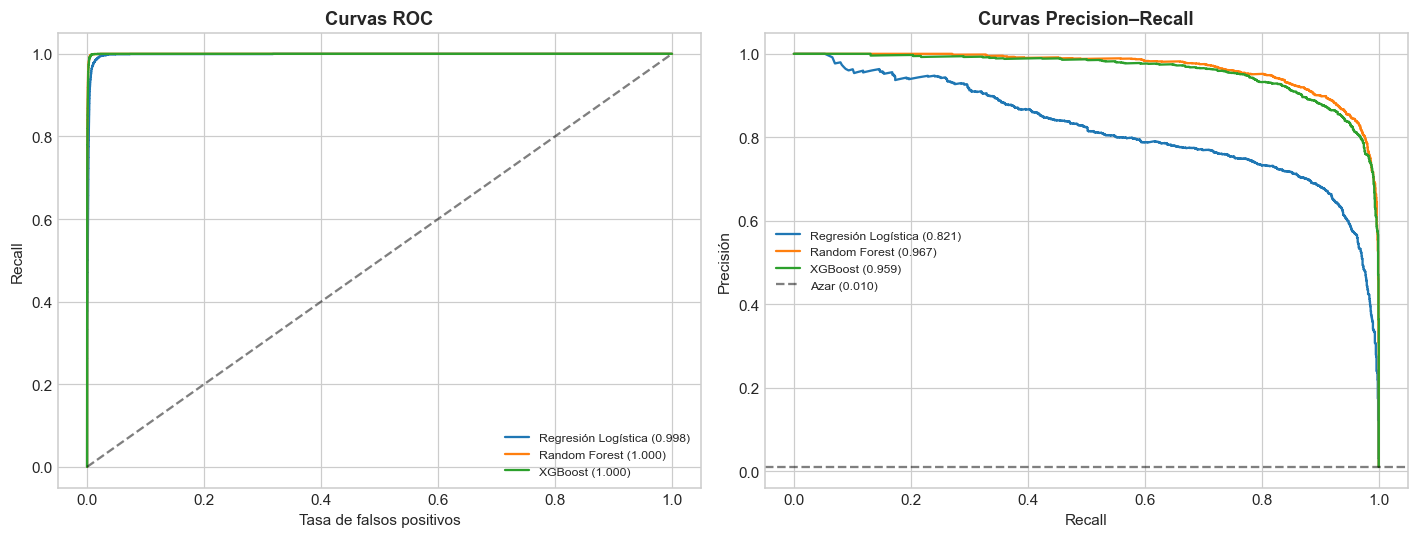

In [20]:
slugs = {
    "Regresión Logística": "regresion_logística",
    "Random Forest": "random_forest",
    "XGBoost": "xgboost",
}
y_test = predicciones_test["alta_cyano"].to_numpy()
prevalencia_test = y_test.mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for modelo, slug in slugs.items():
    prob = predicciones_test[f"prob_{slug}"].to_numpy()
    fpr, tpr, _ = roc_curve(y_test, prob)
    precision_pr, recall_pr, _ = precision_recall_curve(y_test, prob)
    roc_auc = metricas_operativas.loc[metricas_operativas["modelo"] == modelo, "roc_auc"].iloc[0]
    pr_auc = metricas_operativas.loc[metricas_operativas["modelo"] == modelo, "pr_auc"].iloc[0]
    axes[0].plot(fpr, tpr, label=f"{modelo} ({roc_auc:.3f})")
    axes[1].plot(recall_pr, precision_pr, label=f"{modelo} ({pr_auc:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[0].set(xlabel="Tasa de falsos positivos", ylabel="Recall", title="Curvas ROC")
axes[1].axhline(prevalencia_test, color="k", linestyle="--", alpha=0.5, label=f"Azar ({prevalencia_test:.3f})")
axes[1].set(xlabel="Recall", ylabel="Precisión", title="Curvas Precision–Recall")
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "07_curvas_roc_pr.png", dpi=180, bbox_inches="tight")
plt.show()


### Lectura de ROC y Precision–Recall

La diagonal de la curva ROC representa un clasificador al azar. Las tres curvas se acercan a la esquina superior izquierda, lo que indica una alta capacidad para ordenar los píxeles positivos por encima de los negativos en distintos umbrales. Los valores mostrados como `1.000` para Random Forest y XGBoost son redondeos a tres decimales: sus ROC-AUC exactos son aproximadamente 0.9996 y 0.9996, respectivamente; no son resultados perfectamente exactos.

ROC-AUC resume discriminación para todos los umbrales, pero no indica por sí sola cuántas alertas o casos omitidos hay con el umbral escogido; esa lectura se obtiene de las matrices de confusión. Dado que la clase positiva es rara (~1 %), PR-AUC complementa mejor a ROC-AUC: compara precisión y recall frente a una línea base de azar cercana a 0.01. Random Forest también lidera esta métrica (`PR-AUC=0.967`), por lo que su buen ROC-AUC no depende únicamente de la abundancia de negativos.

Los AUC muy altos son coherentes con la señal espectral, pero pueden ser optimistas: la división aleatoria por píxeles puede dejar píxeles vecinos de la misma escena en entrenamiento y prueba. Por tanto, estos resultados validan la comparación convencional solicitada, mientras que la generalización a fechas o áreas nuevas deberá confirmarse con validación espacial o temporal por bloques.


## 5.2 Comparación y mejor modelo

La *accuracy* debe interpretarse contra la línea base que siempre predice clase 0. Con una prevalencia cercana al 1 %, esa estrategia ya obtiene alrededor de 99 % de *accuracy* pero tiene `recall=0`. Por eso el ranking se basa principalmente en PR-AUC y F2, no en *accuracy*.


,modelo,umbral,accuracy,precision,recall,f1,f2,roc_auc,pr_auc,balanced_accuracy,specificity,tn,fp,fn,tp
0,Random Forest,0.429184,0.997367,0.804388,0.974529,0.881322,0.934977,0.999647,0.966661,0.986064,0.997598,177766,428,46,1760
1,XGBoost,0.817227,0.996717,0.762646,0.976744,0.856519,0.924819,0.999582,0.959198,0.986832,0.996919,177645,549,42,1764
2,Regresión Logística,0.951581,0.994294,0.653045,0.920266,0.763962,0.850650,0.997805,0.821313,0.957655,0.995045,177311,883,144,1662


Accuracy de la línea base mayoritaria: 0.9900
Mejor modelo por PR-AUC y F2: Random Forest


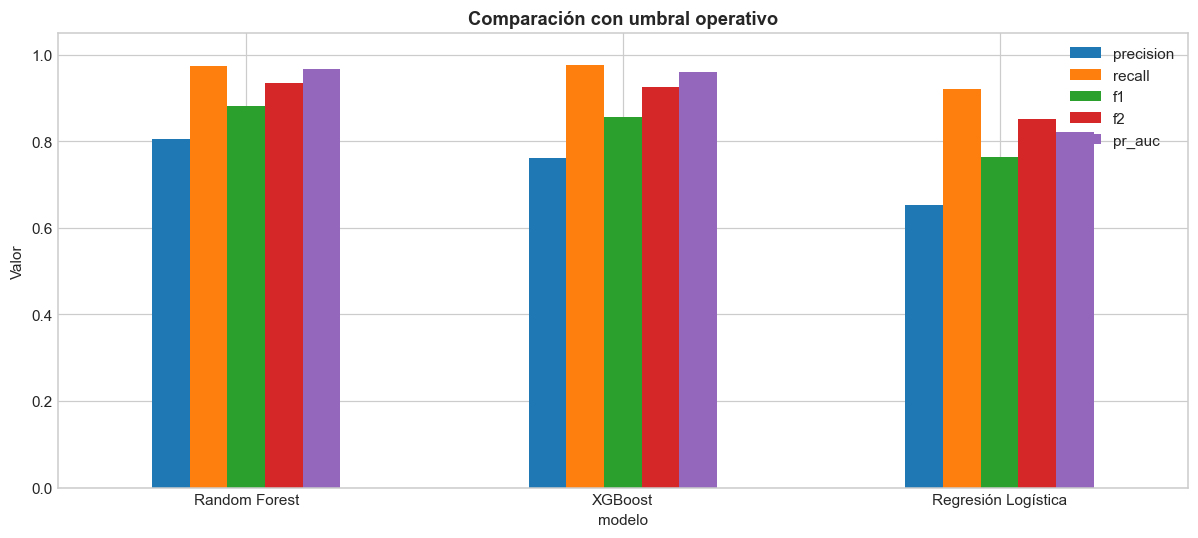

In [21]:
baseline_accuracy = 1 - prevalencia_test
comparacion = metricas_operativas.sort_values(["pr_auc", "f2"], ascending=False).reset_index(drop=True)
display(comparacion[columnas_metricas])

mejor_modelo = comparacion.loc[0, "modelo"]
print(f"Accuracy de la línea base mayoritaria: {baseline_accuracy:.4f}")
print(f"Mejor modelo por PR-AUC y F2: {mejor_modelo}")

fig, ax = plt.subplots(figsize=(11, 5))
metricas_grafico = comparacion.set_index("modelo")[["precision", "recall", "f1", "f2", "pr_auc"]]
metricas_grafico.plot(kind="bar", ax=ax)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Valor")
ax.set_title("Comparación con umbral operativo")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "08_comparacion_modelos.png", dpi=180, bbox_inches="tight")
plt.show()


**Resultado:** Random Forest presenta el mejor equilibrio global. Con el umbral operativo obtiene aproximadamente `PR-AUC=0.967`, `recall=0.975`, `precision=0.804` y `F2=0.935`. En 180,000 píxeles de prueba identifica 1,760 positivos, deja 46 falsos negativos y produce 428 falsos positivos.

XGBoost logra el *recall* más alto (`0.977`) y deja solo 42 falsos negativos, pero produce 549 falsas alertas y obtiene menor PR-AUC/F2 que Random Forest. La regresión logística ofrece una referencia interpretable; con umbral 0.5 alcanza un *recall* muy alto, pero a costa de miles de falsas alertas.


## 5.3 Interpretación ambiental de los errores

### Falso positivo: predice presencia elevada donde realmente es baja

Puede activar inspecciones, muestreos, advertencias o restricciones innecesarias. Esto consume recursos, afecta actividades recreativas y puede reducir la confianza pública si las alertas falsas son frecuentes.

### Falso negativo: no detecta una zona con presencia elevada

Es el error ambientalmente más grave: una floración puede permanecer sin vigilancia, retrasar el muestreo de toxinas y exponer a personas, animales y ecosistemas. También impide actuar tempranamente sobre una zona que podría expandirse.

Por lo tanto, se prioriza reducir falsos negativos, pero sin ignorar el costo operativo de miles de falsos positivos. **F2** es la métrica principal de umbral porque pondera el *recall* cuatro veces más que la precisión; **PR-AUC** se usa para comparar la capacidad de ranking bajo desbalance.

Random Forest se recomienda para continuar a validación espacial porque combina el mejor F2 y PR-AUC con `recall≈0.975`. Si la política ambiental exigiera sensibilidad casi absoluta, podría reducirse todavía más su umbral, aceptando más falsas alarmas; esa decisión debe fijarse con los gestores y costos reales.


## 5.4 Comprobación de coherencia y límites

Los resultados son matemáticamente coherentes: todos los modelos superan ampliamente la PR-AUC aleatoria (~1 %), las matrices concuerdan con las métricas y el test es común. El desempeño alto es plausible porque B07/B8A captan señal de biomasa y porque el split aleatorio coloca píxeles vecinos de una misma escena en entrenamiento y prueba.

Sin embargo, **no debe interpretarse como capacidad demostrada para generalizar a zonas o fechas nuevas**. La autocorrelación espacial hace optimista esta evaluación convencional. También hay solo 37 positivos de Atitlán en el test, por lo que sus métricas específicas son inestables. La conclusión final deberá esperar la validación por bloques espaciales y temporal solicitada en los ejercicios posteriores.



In [22]:
filas_lago = []
for lago, grupo in predicciones_test.groupby("lago", observed=True):
    for modelo, slug in slugs.items():
        prob = grupo[f"prob_{slug}"].to_numpy()
        umbral = manifest_modelos["umbrales_operativos"][modelo]
        pred = prob >= umbral
        filas_lago.append({
            "lago": lago,
            "modelo": modelo,
            "n_test": len(grupo),
            "positivos_reales": int(grupo["alta_cyano"].sum()),
            "precision": precision_score(grupo["alta_cyano"], pred, zero_division=0),
            "recall": recall_score(grupo["alta_cyano"], pred, zero_division=0),
            "pr_auc": average_precision_score(grupo["alta_cyano"], prob),
        })

metricas_por_lago = pd.DataFrame(filas_lago)
display(metricas_por_lago)
metricas_por_lago.to_csv(OUTPUT_DIR / "09_metricas_modelos_por_lago.csv", index=False)


,lago,modelo,n_test,positivos_reales,precision,recall,pr_auc
0,amatitlan,Regresión Logística,19765,1769,0.681135,0.922555,0.850214
1,amatitlan,Random Forest,19765,1769,0.807190,0.977388,0.969067
2,amatitlan,XGBoost,19765,1769,0.772180,0.979084,0.962073
3,atitlan,Regresión Logística,160235,37,0.201342,0.810811,0.326826
4,atitlan,Random Forest,160235,37,0.673913,0.837838,0.760961
5,atitlan,XGBoost,160235,37,0.457143,0.864865,0.658953
